In [ ]:
# Iris Flower Classification
# OASIS INFOBYTE - Data Science Internship
# Task 1

## 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Import Libraries

In [3]:
iris = load_iris()

X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = pd.Series(iris.target, name="species")

df = X.copy()
df["species"] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [4]:
print("Dataset Shape:", df.shape)
print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nStatistical Summary:")
display(df.describe())

Dataset Shape: (150, 5)

Data Types:
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
species                int64
dtype: object

Missing Values:
sepal length (cm)    0
sepal width (cm)     0
petal length (cm)    0
petal width (cm)     0
species              0
dtype: int64

Statistical Summary:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


## 3. Exploratory Data Analysis

In [5]:
# Convert species numbers into flower names
df["species_name"] = df["species"].map({
    0: "Setosa",
    1: "Versicolor",
    2: "Virginica"
})

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species,species_name
0,5.1,3.5,1.4,0.2,0,Setosa
1,4.9,3.0,1.4,0.2,0,Setosa
2,4.7,3.2,1.3,0.2,0,Setosa
3,4.6,3.1,1.5,0.2,0,Setosa
4,5.0,3.6,1.4,0.2,0,Setosa


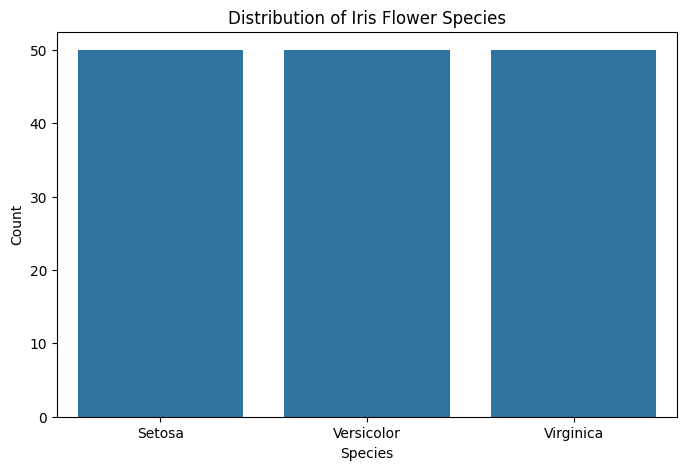

In [6]:
# Count of each species

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x="species_name")

plt.title("Distribution of Iris Flower Species")
plt.xlabel("Species")
plt.ylabel("Count")

plt.show()

## 4. Data Visualization

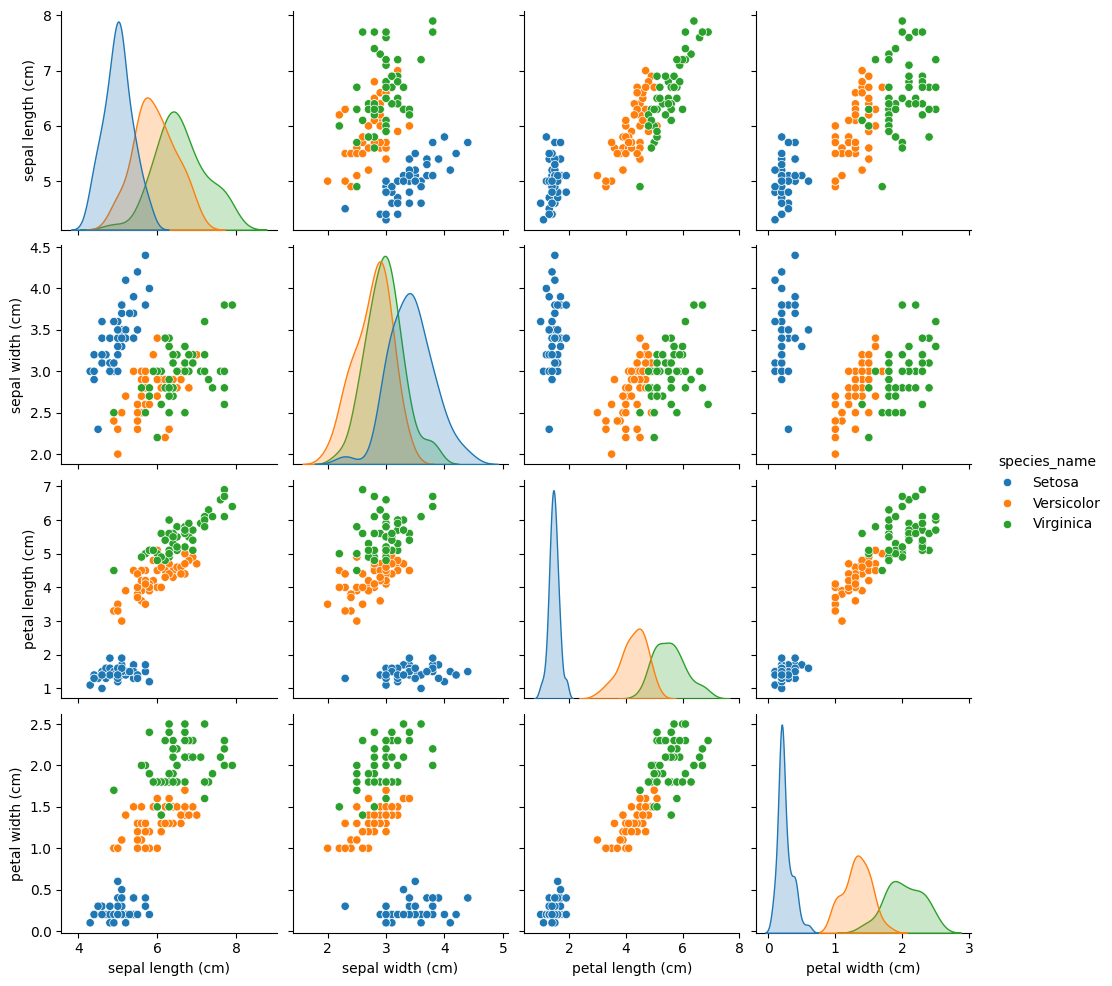

In [7]:
# Pairplot to visualize relationships between features

sns.pairplot(
    df,
    hue="species_name",
    vars=iris.feature_names
)

plt.show()

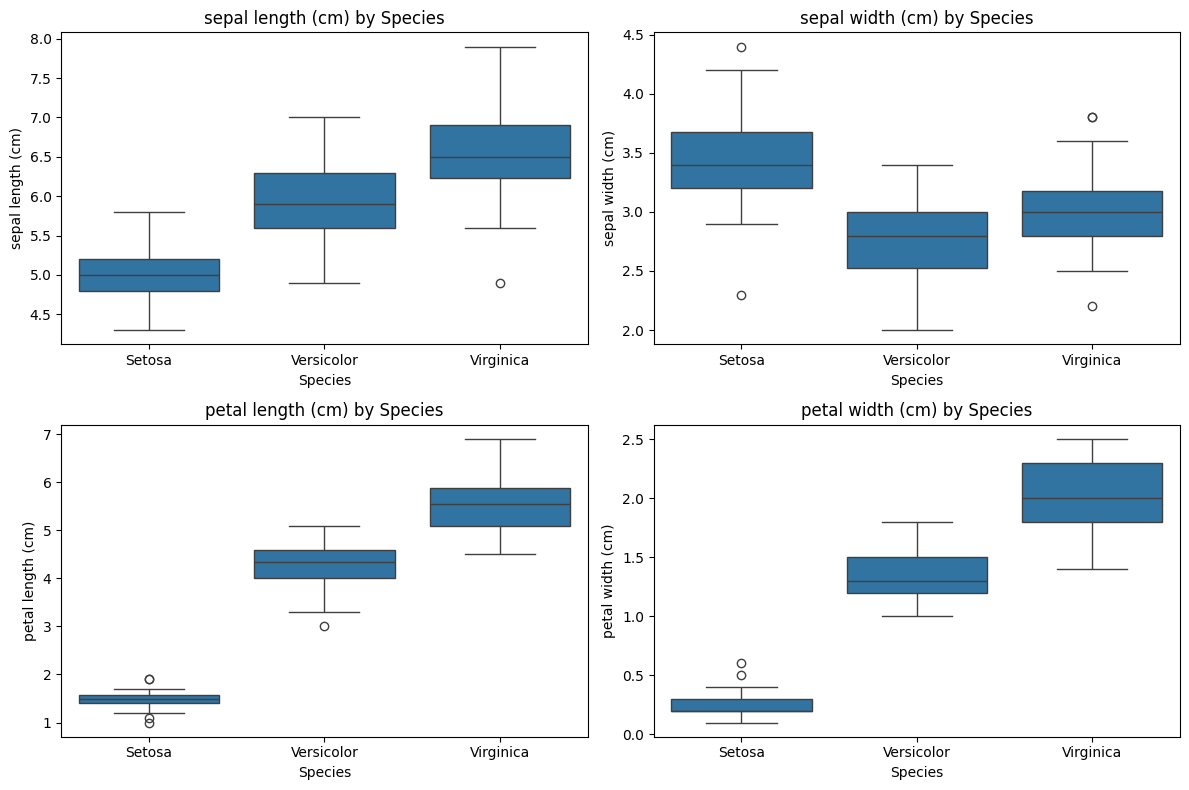

In [13]:
# Box plots for all numerical features

plt.figure(figsize=(12, 8))

for i, feature in enumerate(iris.feature_names, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(data=df, x="species_name", y=feature)
    plt.title(f"{feature} by Species")
    plt.xlabel("Species")
    plt.ylabel(feature)

plt.tight_layout()
plt.show()




## Feature Extraction

Based on the EDA and visualizations, petal length and petal width are the most useful features for classifying Iris flower species.

Petal length and petal width show clear differences between Setosa, Versicolor, and Virginica. Sepal length and sepal width have more overlap between the species.

Therefore, petal length and petal width are considered the most important features for distinguishing the three Iris species.

    

In [15]:
# Select features and target

X = df[iris.feature_names]
y = df["species"]

print("Features (X):")
display(X.head())

print("\nTarget (y):")
display(y.head())

Features (X):


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



Target (y):


0    0
1    0
2    0
3    0
4    0
Name: species, dtype: int64

In [16]:
# Split data into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 120
Testing samples: 30


In [17]:
# Model 1: Logistic Regression

logistic_model = LogisticRegression(max_iter=200)

# Train the model
logistic_model.fit(X_train, y_train)

# Make predictions
y_pred_logistic = logistic_model.predict(X_test)

# Calculate accuracy
logistic_accuracy = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:", logistic_accuracy)

Logistic Regression Accuracy: 0.9666666666666667


In [18]:
# Model 2: K-Nearest Neighbors (KNN)

knn_model = KNeighborsClassifier(n_neighbors=5)

# Train the model
knn_model.fit(X_train, y_train)

# Make predictions
y_pred_knn = knn_model.predict(X_test)

# Calculate accuracy
knn_accuracy = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:", knn_accuracy)

KNN Accuracy: 1.0


In [19]:
# Compare Model Accuracies

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "K-Nearest Neighbors"],
    "Accuracy": [logistic_accuracy, knn_accuracy]
})

display(model_comparison)

,Model,Accuracy
0,Logistic Regression,0.966667
1,K-Nearest Neighbors,1.000000


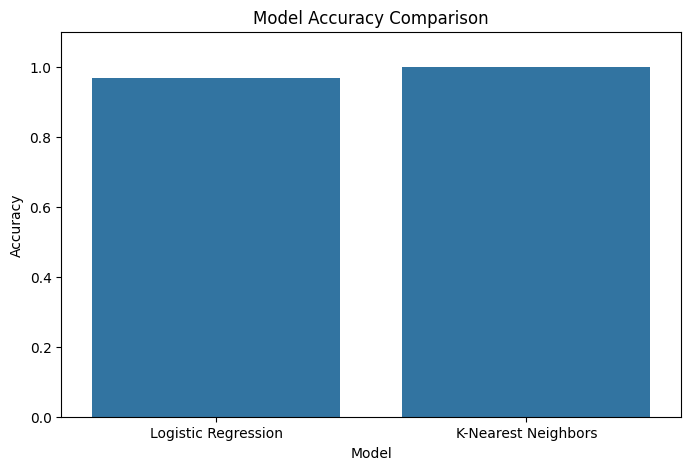

In [20]:
# Visualize Model Accuracy Comparison

plt.figure(figsize=(8, 5))

sns.barplot(
    data=model_comparison,
    x="Model",
    y="Accuracy"
)

plt.title("Model Accuracy Comparison")
plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.ylim(0, 1.1)

plt.show()

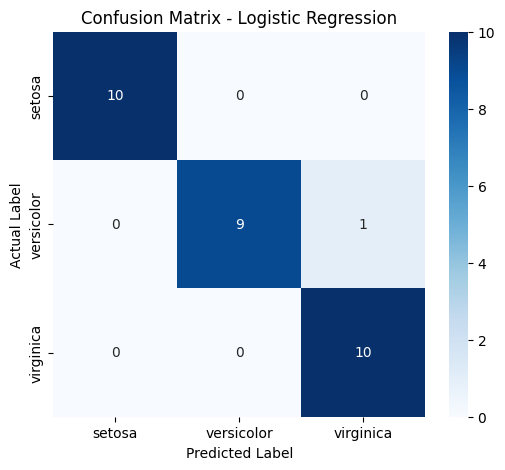

In [21]:
# Confusion Matrix - Logistic Regression

cm_logistic = confusion_matrix(y_test, y_pred_logistic)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_logistic,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

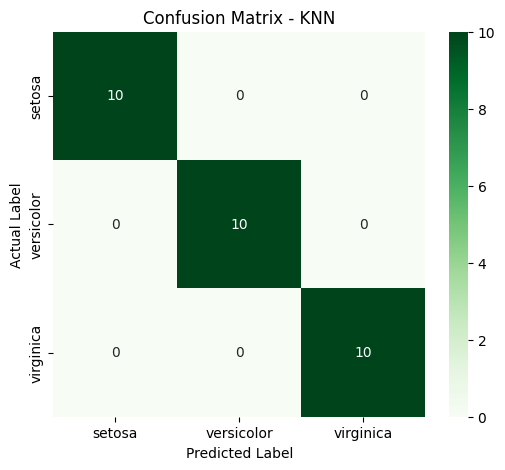

In [22]:
# Confusion Matrix - KNN

cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm_knn,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)

plt.title("Confusion Matrix - KNN")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

In [23]:
# Classification Report - Logistic Regression

print("Classification Report - Logistic Regression")
print(classification_report(
    y_test,
    y_pred_logistic,
    target_names=iris.target_names
))

Classification Report - Logistic Regression
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      0.90      0.95        10
   virginica       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



In [24]:
# Classification Report - KNN

print("Classification Report - KNN")
print(classification_report(
    y_test,
    y_pred_knn,
    target_names=iris.target_names
))

Classification Report - KNN
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



In [25]:
# Final Model Comparison

print("Model Performance")
print("-" * 30)

print(f"Logistic Regression Accuracy: {logistic_accuracy:.2%}")
print(f"KNN Accuracy: {knn_accuracy:.2%}")

if knn_accuracy > logistic_accuracy:
    print("\nBest Model: K-Nearest Neighbors (KNN)")
elif logistic_accuracy > knn_accuracy:
    print("\nBest Model: Logistic Regression")
else:
    print("\nBoth models have the same accuracy.")

Model Performance
------------------------------
Logistic Regression Accuracy: 96.67%
KNN Accuracy: 100.00%

Best Model: K-Nearest Neighbors (KNN)


## Conclusion

In this project, the Iris flower dataset was analyzed using exploratory data analysis and visualization techniques.

Two machine learning classification models were trained and evaluated:

- Logistic Regression achieved an accuracy of 96.67%.
- K-Nearest Neighbors (KNN) achieved an accuracy of 100%.

Based on the test-set accuracy, K-Nearest Neighbors performed better than Logistic Regression for this dataset.

The confusion matrix and classification report were also used to evaluate the models using precision, recall, and F1-score.

The exploratory analysis showed that petal length and petal width were particularly useful for distinguishing the three Iris species.

Therefore, K-Nearest Neighbors was selected as the best-performing model among the two models tested.

## Project Summary

Dataset: Iris Flower Dataset

Problem Type:Multiclass Classification

Models Used:
1. Logistic Regression
2. K-Nearest Neighbors (KNN)

Best Model: K-Nearest Neighbors (KNN)

Best Accuracy: 100%